# Global Tech Layoffs Analysis (2020–2024)

## Objective
To analyse the global tech layoff wave between 2020 and 2024 — identifying which industries, countries, and company funding stages were hit hardest, how layoffs trended over time, and whether a company's size or capital raised has any relationship with the scale of job cuts.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

pd.set_option('display.max_columns', None)

## 2. Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Rudra Barot\OneDrive\Desktop\90-DAY-JOB-SYSTEM\LAYOFFS-EDA-PYTHON\layoffs_dataset.csv")

## 3. Initial Data Profiling
This section explores the structure, size, data types, and statistical summary of the dataset.

In [3]:
df.shape

(3642, 12)

In [4]:
df.head()

,Company,Location_HQ,Industry,Laid_Off_Count,Date,Source,Funds_Raised,Stage,Date_Added,Country,Percentage,List_of_Employees_Laid_Off
0,Oda,Oslo,Food,150.0,2024-06-05,https://techcrunch.com/2024/06/05/softbank-bac...,691.0,Unknown,2024-06-05 18:01:25,Norway,NaN,Unknown
1,Pagaya,Tel Aviv,Finance,100.0,2024-06-05,https://www.calcalistech.com/ctechnews/article...,2000.0,Post-IPO,2024-06-05 23:11:24,Israel,0.20,Unknown
2,Aleph Farms,Tel Aviv,Food,30.0,2024-06-05,https://www.calcalistech.com/ctechnews/article...,119.0,Unknown,2024-06-05 23:13:43,Israel,0.30,Unknown
3,MoonPay,Dover,Crypto,30.0,2024-06-05,https://www.theblock.co/post/298638/moonpay-la...,651.0,Unknown,2024-06-05 23:12:47,United States,0.10,Unknown
4,Yext,New York City,Marketing,NaN,2024-06-05,https://www.investing.com/news/economy-news/ye...,117.0,Post-IPO,2024-06-05 18:02:40,United States,0.12,Unknown


In [5]:
df.dtypes

Company                        object
Location_HQ                    object
Industry                       object
Laid_Off_Count                float64
Date                           object
Source                         object
Funds_Raised                  float64
Stage                          object
Date_Added                     object
Country                        object
Percentage                    float64
List_of_Employees_Laid_Off     object
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3642 entries, 0 to 3641
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company                     3642 non-null   object 
 1   Location_HQ                 3642 non-null   object 
 2   Industry                    3642 non-null   object 
 3   Laid_Off_Count              2389 non-null   float64
 4   Date                        3642 non-null   object 
 5   Source                      3642 non-null   object 
 6   Funds_Raised                3252 non-null   float64
 7   Stage                       3642 non-null   object 
 8   Date_Added                  3642 non-null   object 
 9   Country                     3642 non-null   object 
 10  Percentage                  2342 non-null   float64
 11  List_of_Employees_Laid_Off  3642 non-null   object 
dtypes: float64(3), object(9)
memory usage: 341.6+ KB


In [7]:
df.describe()

,Laid_Off_Count,Funds_Raised,Percentage
count,2389.000000,3252.000000,2342.000000
mean,257.926329,798.569494,0.281216
std,829.432277,4758.393161,0.287294
min,3.000000,0.000000,0.000000
25%,40.000000,51.000000,0.100000
50%,80.000000,166.000000,0.170000
75%,181.000000,469.250000,0.300000
max,14000.000000,121900.000000,1.000000


In [8]:
df.describe(include='object')

,Company,Location_HQ,Industry,Date,Source,Stage,Date_Added,Country,List_of_Employees_Laid_Off
count,3642,3642,3642,3642,3642,3642,3642,3642,3642
unique,2596,240,31,825,3407,16,3603,63,48
top,Google,SF Bay Area,Finance,2020-04-02,Internal memo,Post-IPO,2020-03-28 20:52:49,United States,Unknown
freq,12,905,451,27,98,768,40,2369,3595



Missing value percentages were calculated to identify columns that may require cleaning or imputation before analysis.

In [9]:
# Null percentage per column
null_percentage = (
    (df.isnull().sum() / len(df) * 100)
    .round(1)
    .sort_values(ascending=False)
)

null_percentage[null_percentage > 0]

Percentage        35.7
Laid_Off_Count    34.4
Funds_Raised      10.7
dtype: float64

In [10]:
df.duplicated().sum()

0

## 4. Data Cleaning

### Creating a Raw Backup Before Cleaning

Before making any modifications to the dataset, a backup copy is created using 
`df.copy()`. This ensures the original raw data is always recoverable if any 
cleaning step produces unexpected results — without needing to reload the CSV. 

All cleaning operations will be applied to `df` while `df_raw` remains untouched 
throughout the notebook.

In [11]:

df_raw = df.copy()
df_raw.head()



,Company,Location_HQ,Industry,Laid_Off_Count,Date,Source,Funds_Raised,Stage,Date_Added,Country,Percentage,List_of_Employees_Laid_Off
0,Oda,Oslo,Food,150.0,2024-06-05,https://techcrunch.com/2024/06/05/softbank-bac...,691.0,Unknown,2024-06-05 18:01:25,Norway,NaN,Unknown
1,Pagaya,Tel Aviv,Finance,100.0,2024-06-05,https://www.calcalistech.com/ctechnews/article...,2000.0,Post-IPO,2024-06-05 23:11:24,Israel,0.20,Unknown
2,Aleph Farms,Tel Aviv,Food,30.0,2024-06-05,https://www.calcalistech.com/ctechnews/article...,119.0,Unknown,2024-06-05 23:13:43,Israel,0.30,Unknown
3,MoonPay,Dover,Crypto,30.0,2024-06-05,https://www.theblock.co/post/298638/moonpay-la...,651.0,Unknown,2024-06-05 23:12:47,United States,0.10,Unknown
4,Yext,New York City,Marketing,NaN,2024-06-05,https://www.investing.com/news/economy-news/ye...,117.0,Post-IPO,2024-06-05 18:02:40,United States,0.12,Unknown


### Cleaning Decision 1: Dropped Irrelevant Columns

Three columns were removed from the dataset as they carry no analytical value:

- `Source` — a reference URL pointing to the news article that reported the layoff. 
  This is a data provenance field, not a variable that can be analysed.
- `Date_Added` — the timestamp of when the row was entered into the tracker, not 
  when the layoff actually occurred. Using this as a time variable would produce 
  misleading trends.
- `List_of_Employees_Laid_Off` — 98.7% of values in this column are `'Unknown'` 
  (3,595 of 3,642 rows). A column that is effectively empty adds noise and gives 
  any reader the false impression that named employee data exists when it does not.

Removing these columns reduces the DataFrame from 12 to 9 columns and ensures 
every remaining variable contributes directly to the analysis.

In [12]:
df = df.drop(columns=[
    'Source',
    'Date_Added',
    'List_of_Employees_Laid_Off'
])

In [13]:
df.shape

(3642, 9)

### Cleaning Decision 2: Converted Date Column to Datetime and Extracted Year and Month

The `Date` column was loaded as `object` (string) by pandas — in this format, 
pandas treats dates as plain text, making any time-based operation impossible. 
The column was converted to `datetime64` using `pd.to_datetime()`, after which 
`Year` and `Month` were extracted as separate columns. This enables clean 
time-based `groupby` analysis throughout the notebook without repeatedly calling 
`.dt.year` or `.dt.month` inline on every operation.

In [14]:
df['Date'] = pd.to_datetime(df['Date'])


In [20]:
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [21]:
df[['Date', 'Year', 'Month']].dtypes

Date     datetime64[ns]
Year              int32
Month             int32
dtype: object

In [22]:
print(df[['Date', 'Year', 'Month']].head())

        Date  Year  Month
0 2024-06-05  2024      6
1 2024-06-05  2024      6
2 2024-06-05  2024      6
3 2024-06-05  2024      6
4 2024-06-05  2024      6


### Cleaning Decision 3: Retained Rows With Missing Layoff Metrics

`Laid_Off_Count` (34.4% null) and `Percentage` (35.7% null) cannot be imputed — these are real business events and fabricating a number would distort the analysis. Nulls exist because companies typically disclose only one of the two figures. The full dataset is preserved and `dropna(subset=['Laid_Off_Count'])` is applied only at the point of aggregation, ensuring each analysis uses the maximum honest data available.

# BUSINESS QUESTIONS

## Business Question 1 — Which Industries Were Most Impacted by Layoffs?

Not all industries were affected equally by the tech downturn. This analysis 
aggregates total layoffs by industry to identify which sectors were hit hardest 
and understand broader industry-level vulnerability patterns.

The underlying hypothesis is that consumer-facing sectors — which expanded 
aggressively during the pandemic boom and are highly sensitive to shifts in 
consumer spending — would be most exposed when market conditions tightened.

In [91]:
# Aggregate total layoffs by industry
# This helps identify which sectors were most affected overall

industry_layoffs = (
    df.groupby('Industry')['Laid_Off_Count']
      .sum()
      .sort_values(ascending=False)
      .reset_index(name='Total_Laid_Off')
)

# Preview industries with the highest layoff totals
industry_layoffs.head(10)

,Industry,Total_Laid_Off
0,Retail,70157.0
1,Consumer,67675.0
2,Transportation,59417.0
3,Other,59261.0
4,Food,45625.0
5,Finance,43103.0
6,Hardware,37750.0
7,Healthcare,36907.0
8,Travel,23132.0
9,Real Estate,19108.0


<Figure size 1200x600 with 0 Axes>

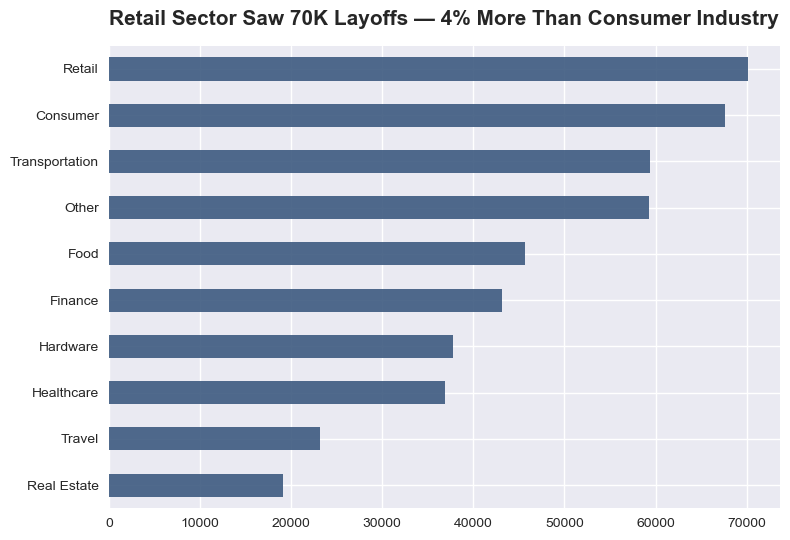

In [92]:
plt.figure(figsize=(12,6))

ax = (
    industry_layoffs.head(10)
    .sort_values(by='Total_Laid_Off')
    .plot(
        kind='barh',
        x='Industry',
        y='Total_Laid_Off',
        color='#3D5A80',
        alpha=0.9,
        legend=False
    )
)

plt.title(
    'Retail Sector Saw 70K Layoffs — 4% More Than Consumer Industry',
    fontsize=15,
    fontweight='bold',
    pad=15
)


plt.ylabel('')
plt.tight_layout()
plt.savefig('chart1_industry_layoffs.png', dpi=150, bbox_inches='tight')
plt.show()

## Business Question 2 — How Did Layoff Trends Evolve Over Time?

Layoffs often reflect broader economic conditions, shifts in investor sentiment, 
and corrections following periods of aggressive hiring. This analysis examines 
how total layoffs changed over time to identify periods of sharp increases or declines.

The underlying hypothesis is that layoffs surged after the post-pandemic hiring boom, 
as companies began reducing workforce size in response to slowing growth, tighter funding conditions, 
and increasing pressure to improve operational efficiency.

In [56]:
# Aggregate total layoffs by year
# This helps identify how workforce reductions changed over time

yearly_layoffs = (
    df.groupby('Year')['Laid_Off_Count']
      .sum()
      .reset_index(name='Total_Laid_Off')
)

# Preview yearly layoff trends
yearly_layoffs

,Year,Total_Laid_Off
0,2020,80998.0
1,2021,15823.0
2,2022,165269.0
3,2023,263180.0
4,2024,90916.0


<Figure size 1000x500 with 0 Axes>

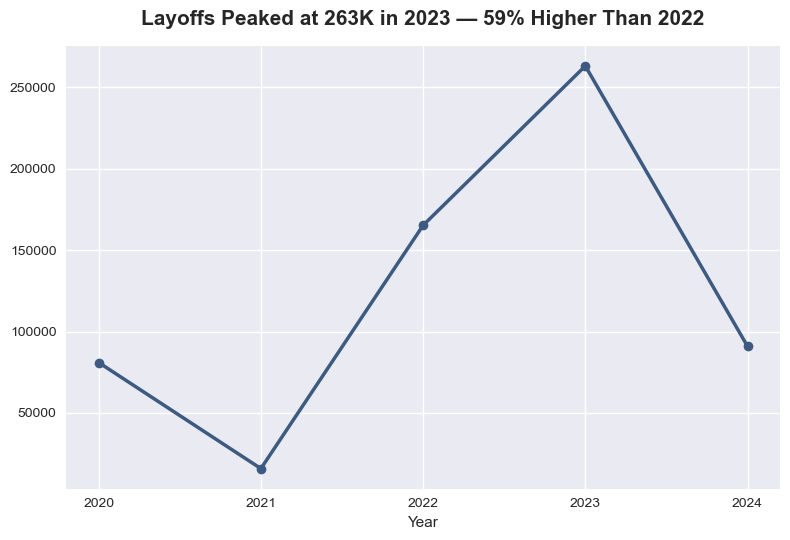

In [93]:
plt.figure(figsize=(10,5))

(
    yearly_layoffs
    .plot(
        kind='line',
        x='Year',
        y='Total_Laid_Off',
        marker='o',
        linewidth=2.5,
        color='#3D5A80',
        legend=False
    )
)

plt.title(
    'Layoffs Peaked at 263K in 2023 — 59% Higher Than 2022',
    fontsize=15,
    fontweight='bold',
    pad=15
)


plt.ylabel('')

plt.xticks(yearly_layoffs['Year'])

plt.tight_layout()
plt.savefig('chart2_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Business Question 3 — Which Funding Stage Had the Highest Average Layoff Count per Company?

Companies at different funding stages often operate under very different growth expectations, financial pressures, and investor demands. This analysis compares the average number of employees laid off per company across funding stages to understand whether company maturity influenced layoff severity.

The underlying hypothesis is that later-stage and post-IPO companies would experience larger layoffs on average due to aggressive expansion during growth periods, followed by stronger pressure to reduce costs and improve profitability during downturns.

In [96]:
# Calculate average layoffs per company by funding stage
# Using averages helps normalize for differences in the number of companies per stage

stage_avg_layoffs = (
    df.groupby('Stage')['Laid_Off_Count']
      .mean()
      .sort_values(ascending=False)
      .reset_index(name='Average_Laid_Off')
)
stage_avg_layoffs

,Stage,Average_Laid_Off
0,Post-IPO,622.784926
1,Series J,468.750000
2,Series I,407.857143
3,Private Equity,305.527778
4,Series H,293.740741
5,Acquired,279.140845
6,Series G,278.250000
7,Subsidiary,218.470588
8,Series F,180.173333
9,Series E,173.551181


<Figure size 1200x600 with 0 Axes>

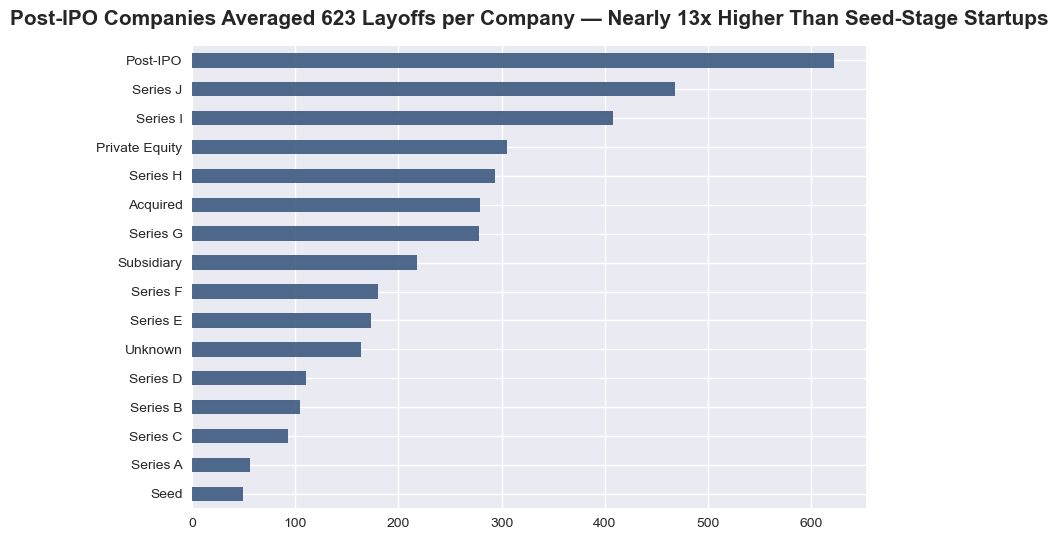

In [94]:
plt.figure(figsize=(12,6))

(
    stage_avg_layoffs
    .sort_values(by='Average_Laid_Off')
    .plot(
        kind='barh',
        x='Stage',
        y='Average_Laid_Off',
        color='#3D5A80',
        alpha=0.9,
        legend=False
    )
)

plt.title(
    'Post-IPO Companies Averaged 623 Layoffs per Company — Nearly 13x Higher Than Seed-Stage Startups',
    fontsize=15,
    fontweight='bold',
    pad=15
)
plt.ylabel('')
plt.tight_layout()
plt.savefig('chart3_stage_layoffs.png', dpi=150, bbox_inches='tight')
plt.show()

## Supporting Analysis — How Did Layoffs Fluctuate Month-to-Month?

While yearly trends highlight broader patterns, monthly analysis provides a more granular view of how layoffs evolved throughout the downturn period.

This analysis helps identify periods of concentrated workforce reductions and reveals whether layoffs occurred gradually or in sharp waves over time.

In [80]:
# Aggregate total layoffs by month
# This helps identify which periods experienced the sharpest workforce reductions

monthly_layoffs = (
    df.groupby('Month')['Laid_Off_Count']
      .sum()
      .reset_index(name='Total_Laid_Off')
)

# preview monthly layoff trends
monthly_layoffs

,Month,Total_Laid_Off
0,1,131139.0
1,2,60094.0
2,3,60755.0
3,4,73601.0
4,5,63871.0
5,6,40821.0
6,7,34080.0
7,8,27069.0
8,9,11358.0
9,10,29219.0


<Figure size 1200x600 with 0 Axes>

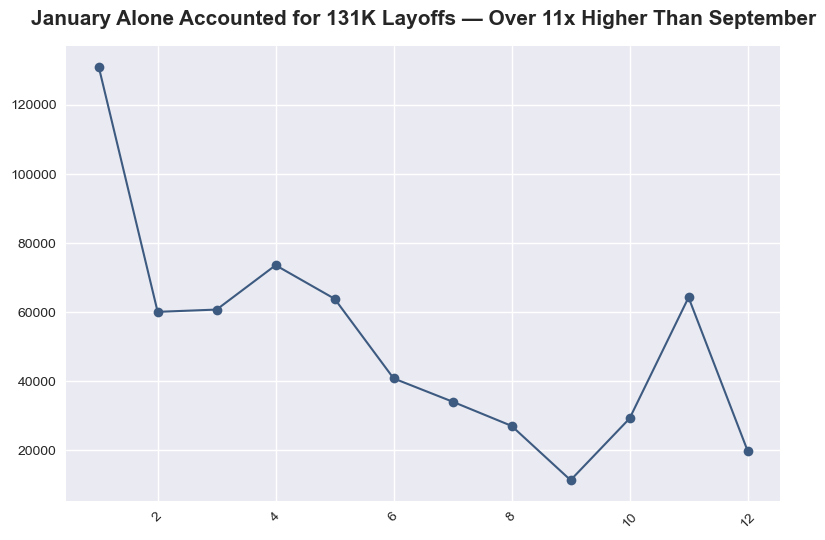

In [95]:
plt.figure(figsize=(12,6))

(
    monthly_layoffs
    .plot(
        kind='line',
        x='Month',
        y='Total_Laid_Off',
        color='#3D5A80',
        linewidth=1.5,
        marker='o',
        legend=False
    )
)

plt.title(
    'January Alone Accounted for 131K Layoffs — Over 11x Higher Than September',
    fontsize=15,
    fontweight='bold',
    pad=15
)

plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart4_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Key Findings & Recommendations

### 🔑 Key Findings

**Finding 1 — Retail and Consumer sectors bore the heaviest burden**
Retail recorded the highest total layoffs of any industry at 70,157, followed 
closely by Consumer at 67,675, together accounting for the two hardest-hit 
sectors. Both industries expanded aggressively during the pandemic boom and 
contracted sharply when consumer spending normalised.

**Finding 2 — 2023 was the peak layoff year, with 263K job cuts**
Layoffs grew 16x from 2021 (15,823) to their 2023 peak (263,180), a dramatic mass 
correction after pandemic-era overhiring. 2024 shows early signs of stabilisation 
at 90,916.

**Finding 3 — Post-IPO companies averaged 623 layoffs, 12x more than Seed stage**
With an average of 623 layoffs per company, Post-IPO firms cut workforces at 
dramatically higher rates than early-stage startups like Seed (49 average). 
Public market pressure and shareholder scrutiny, not company size alone, appears 
to drive more aggressive workforce reductions.

---

### 💡 Recommendations

**Recommendation 1 — Monitor Early Warning Signals to Avoid Reactive Layoffs**
Given the sharp spike in 2023 and concentrated monthly layoffs, companies should monitor key signals like hiring velocity, burn rate, and funding environment shifts. Tracking these indicators regularly can help identify overexpansion before it becomes unsustainable. This enables proactive workforce adjustments rather than reactive layoffs during downturns.


**Recommendation 2 — Treat Post-IPO Status as a Layoff Risk Indicator, Not a Safety Signal**
Given the data, Post-IPO status should be treated as a potential layoff risk indicator rather than a guarantee of job stability. Post-IPO companies recorded the highest average layoffs (~623), indicating significant workforce restructuring even after going public. Investors and Board Members should evaluate headcount trends post-IPO alongside financial performance to better assess organizational stability.